In [1]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../../..")

In [2]:
import pandas as pd

from tqdm import tqdm
from pathlib import Path

from ltr_utility.dataset import load_query_similarity, load_by_query_dataset, DatasetName
from ltr_utility.model_selection import evaluate, show_distr_conf, custom_train

from experiments.wrappers import *

In [3]:
base_path = Path("../../../datasets")
base_result = Path("results")
base_result.mkdir(parents=True, exist_ok=True)

In [4]:
eval_at = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25]
hold_out = (0.5, 0.2, 0.3)
iqr_trim = None  #(25, 75)
query_groups = load_query_similarity(Path("results"))

In [5]:
train, valid, test, train_valid = load_by_query_dataset(base_path, DatasetName.MQ, hold_out=hold_out)

Loading train dataset from cache.
Train data loaded from cache.
Loading valid dataset from cache.
Valid data loaded from cache.
Loading test dataset from cache.
Test data loaded from cache.
---- MQ2007 2007 loaded ----
Filtered out 1 queries with fewer than 10 documents.
---- discard_minority_groups 10 queries ----
---- Get first 500 queries ----
---- max_item 400 -(determistic!) ----
---- Holdout (0.5, 0.2, 0.3) - (determistic!) ----


# LambdaMART

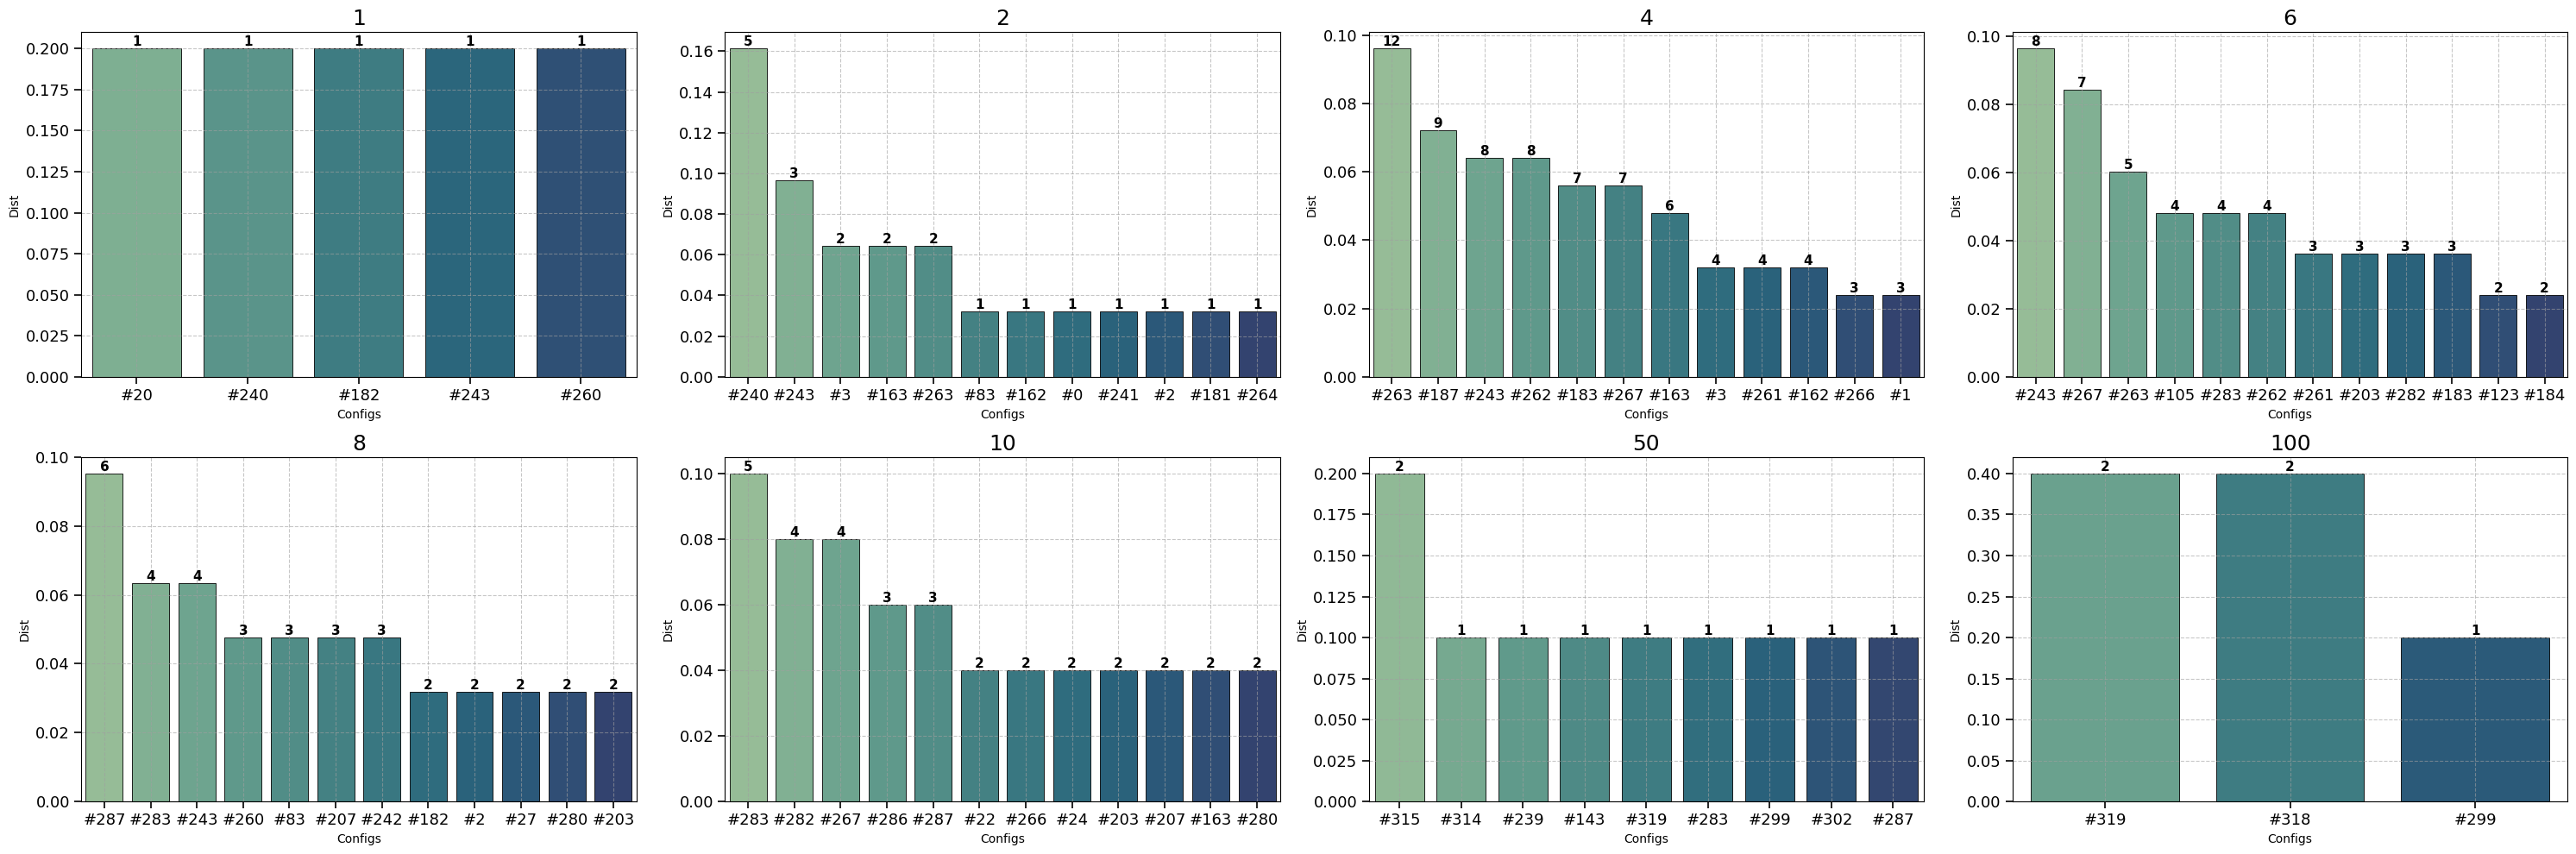

In [6]:
lm_ms = pd.read_json(base_result / "lm_query_model_selection.json")
lm_conf_dist = show_distr_conf(lm_ms)

In [14]:
lm_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:20, 2:240, 4:263, 6:243, 8:287, 10:283, 50:315, 100:319},
    "lm_query_model_selection.json",
    lm_ms,
    "LambdaMART",
    WrapperLGBMRanker
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:04<00:00, 121.72it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:03<00:00, 75.36it/s] 


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:04<00:00, 11.53it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:04<00:00,  2.37it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]


# KNN

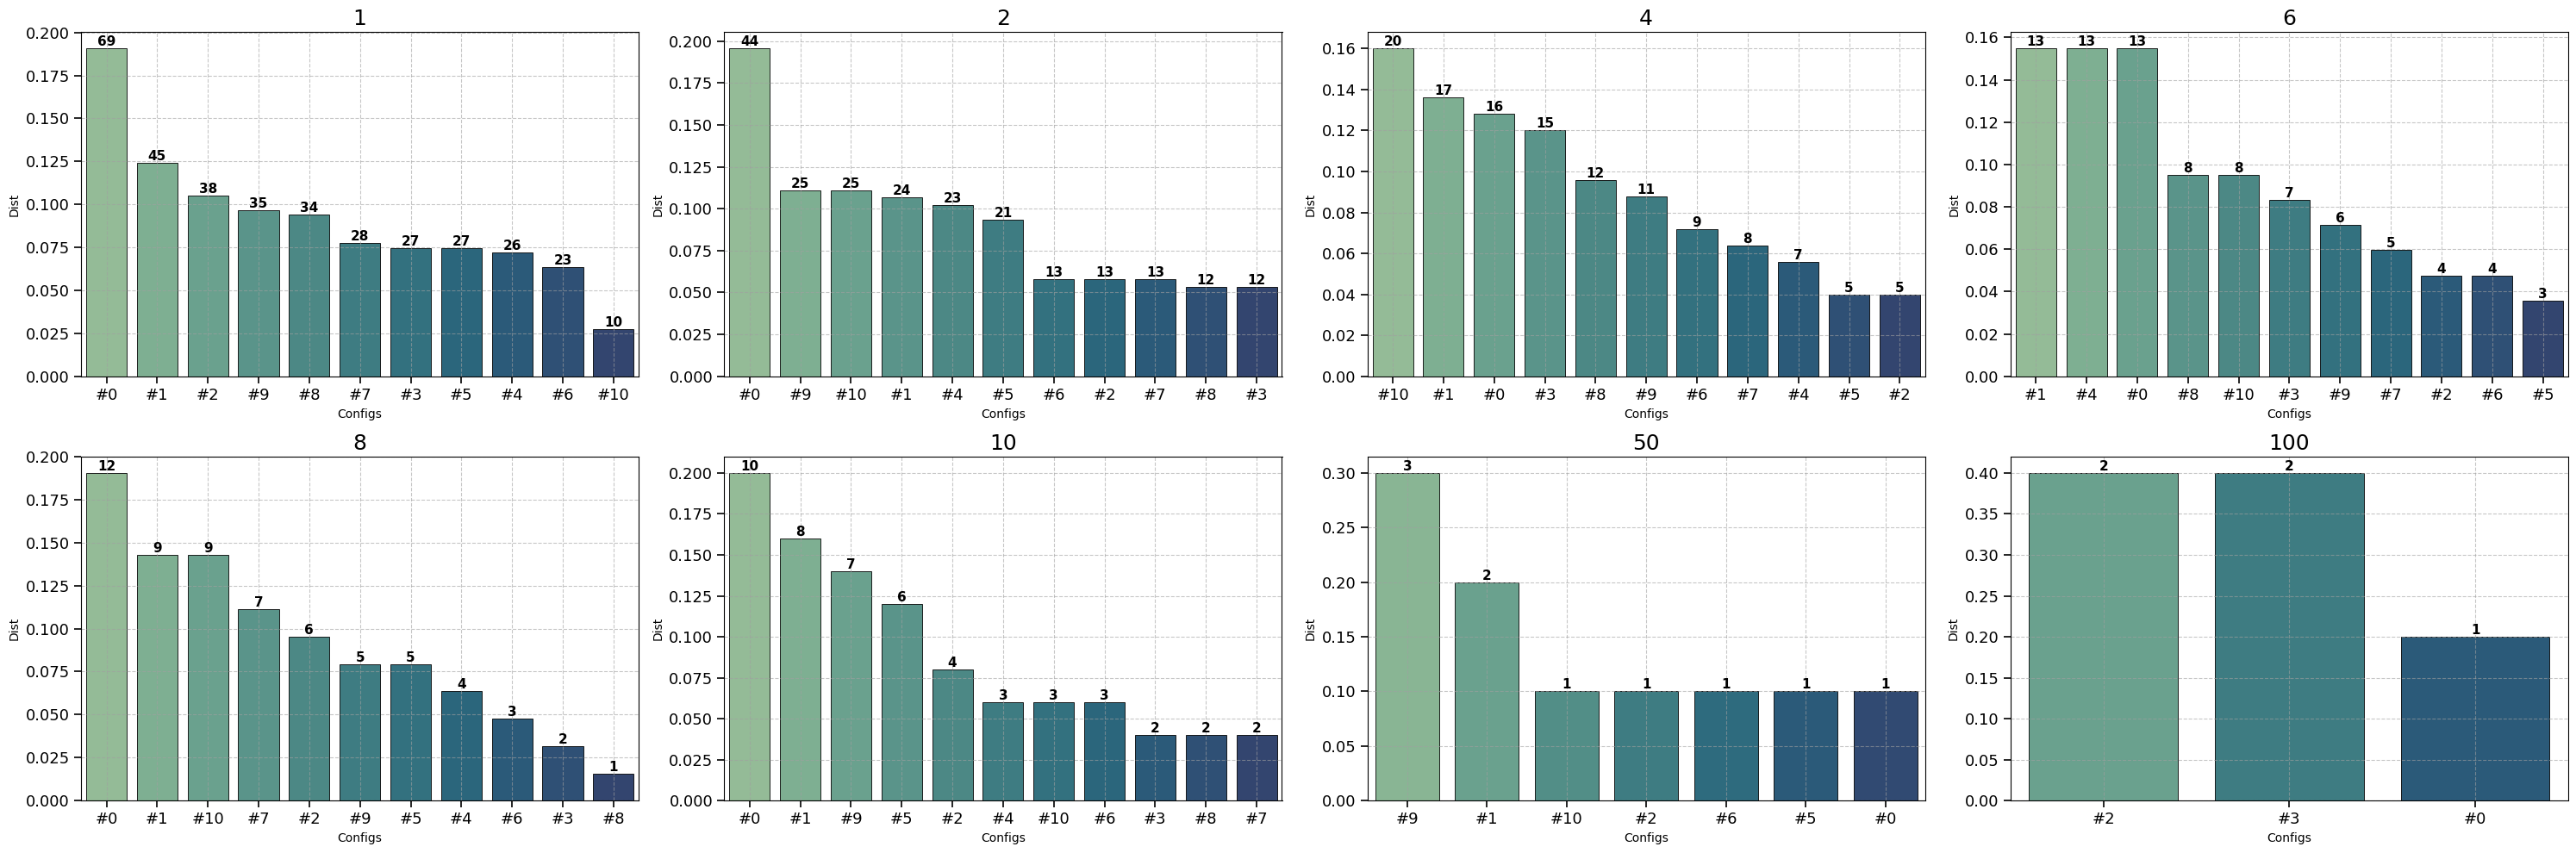

In [7]:
knn_ms = pd.read_json(base_result / "knn_query_model_selection.json")
knn_conf_dist = show_distr_conf(knn_ms)

In [15]:
knn_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:0, 4:10, 6:1, 8:0, 10:0, 50:9, 100:2},
    "knn_query_model_selection.json",
    knn_ms,
    "KNN Regressor",
    WrapperKNN
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 4602.14it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 4047.98it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 3157.22it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 1141.06it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 746.82it/s]


# RuleTreeRank

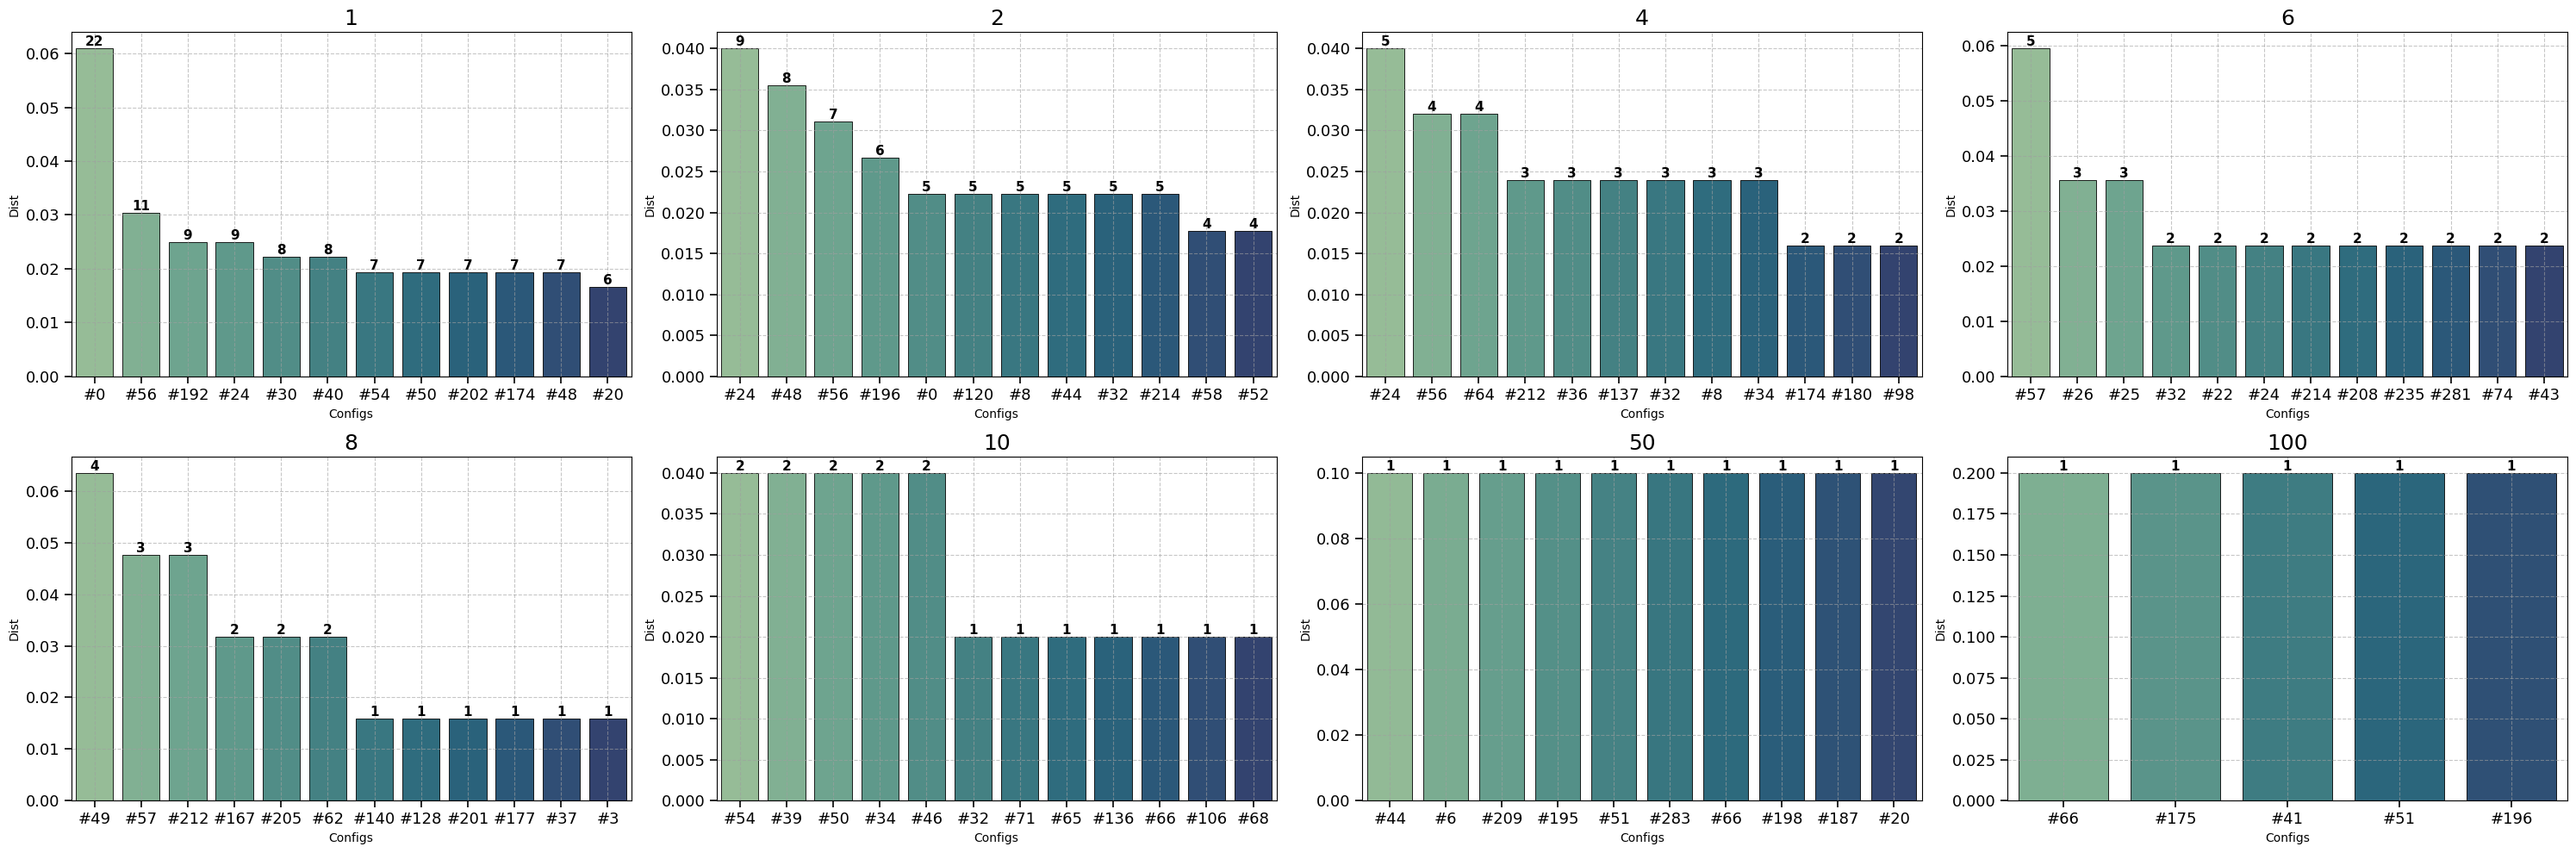

In [8]:
rtr_ms = pd.read_json(base_result / "rtr_query_model_selection.json")
rtr_conf_dist = show_distr_conf(rtr_ms)

In [16]:
rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:24, 4:24, 6:57, 8:49, 10:54, 50:44, 100:66},
    "rtr_query_model_selection.json",
    rtr_ms,
    "RuleTreeRank",
    WrapperRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:27<00:00, 18.43it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:23<00:00, 10.42it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:46<00:00,  4.68s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [03:56<00:00, 47.23s/it]


Eval


# Mixed RuleTreeRank

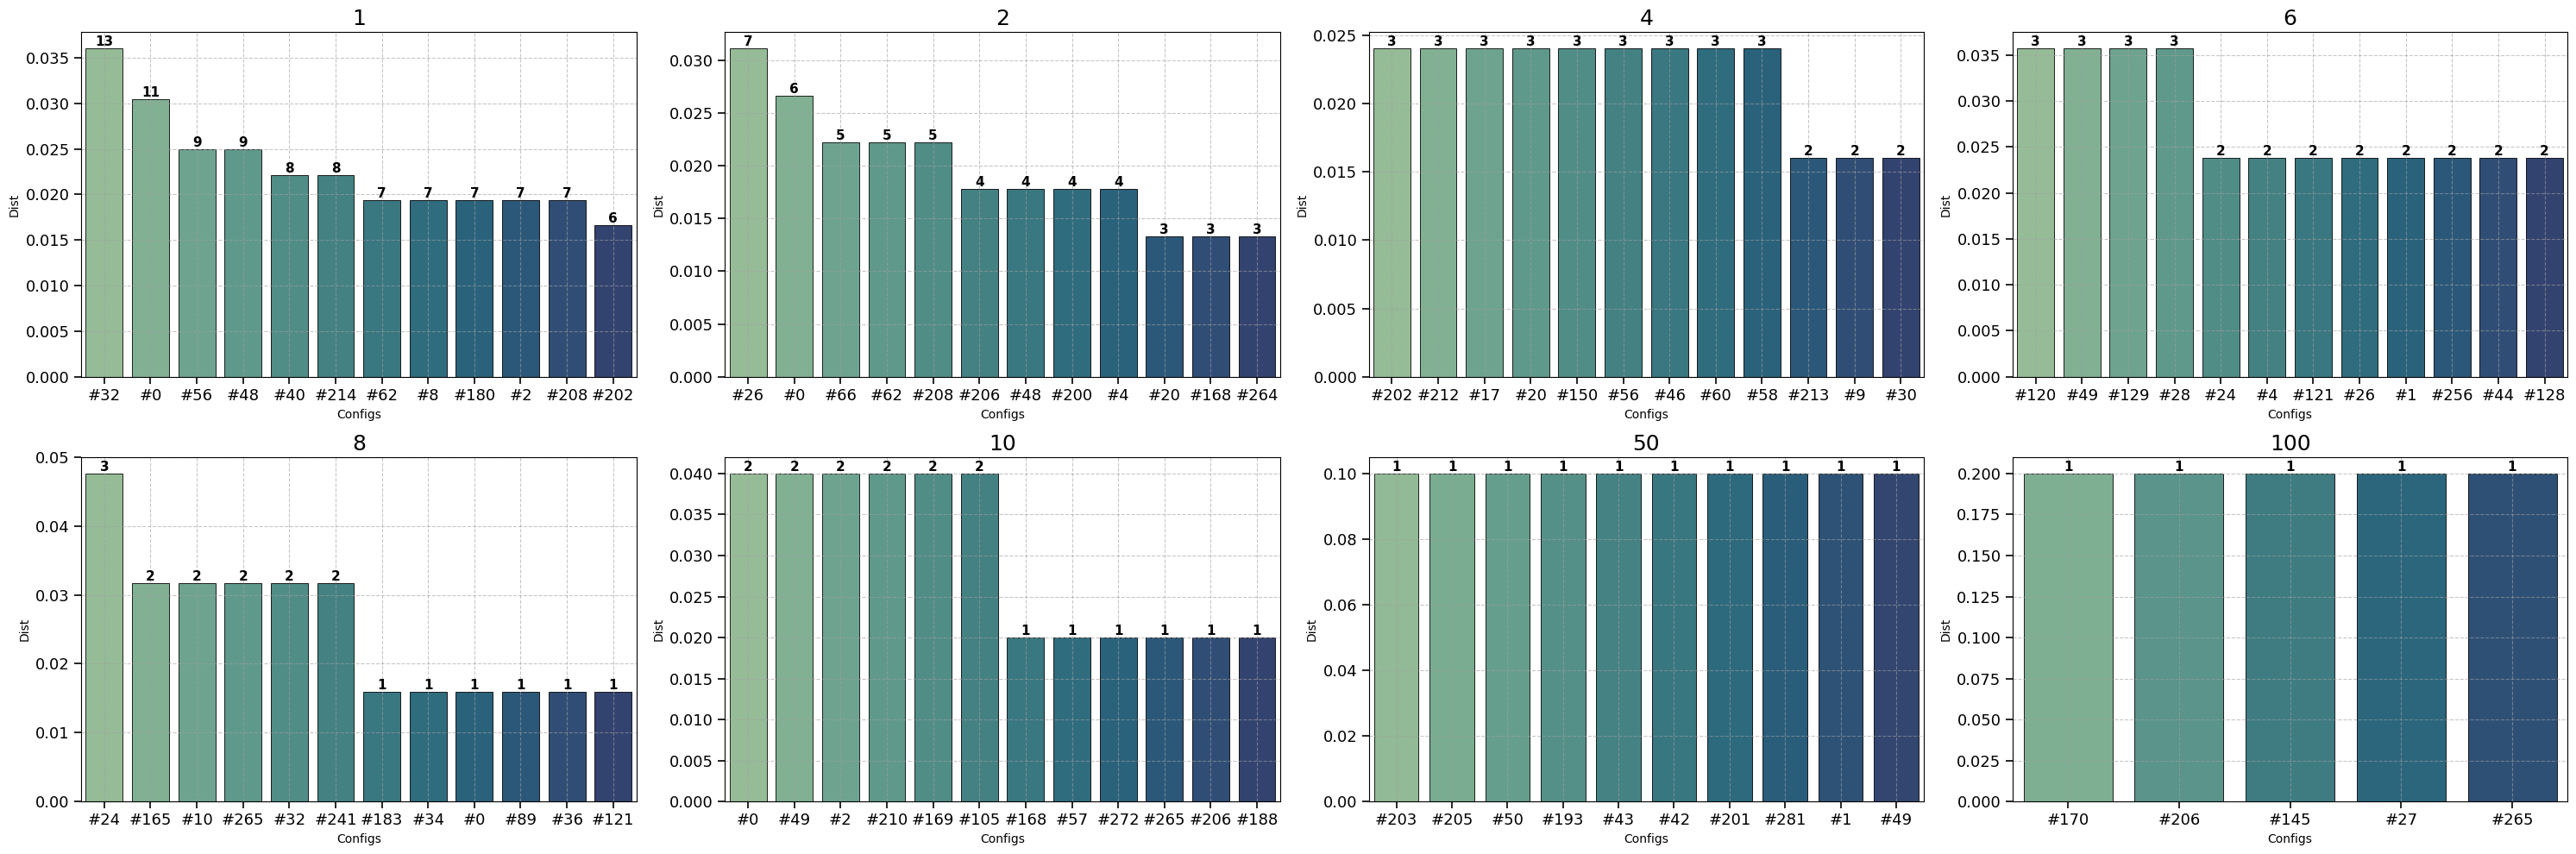

In [6]:
mix_rtr_ms = pd.read_json(base_result / "mix_rtr_query_model_selection.json")
mix_rtr_conf_dist = show_distr_conf(mix_rtr_ms)

In [7]:
mix_rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:32, 2:26, 4:212, 6:120, 8:24, 10:0, 50:203, 100:170},
    "mix_rtr_query_model_selection.json",
    mix_rtr_ms,
    "Mix-RuleTreeRank",
    WrapperMixRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:37<00:00, 13.26it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:21<00:00, 11.70it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:06<00:00,  1.61it/s]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:08<00:00,  1.68s/it]


Eval


# KNN PDT

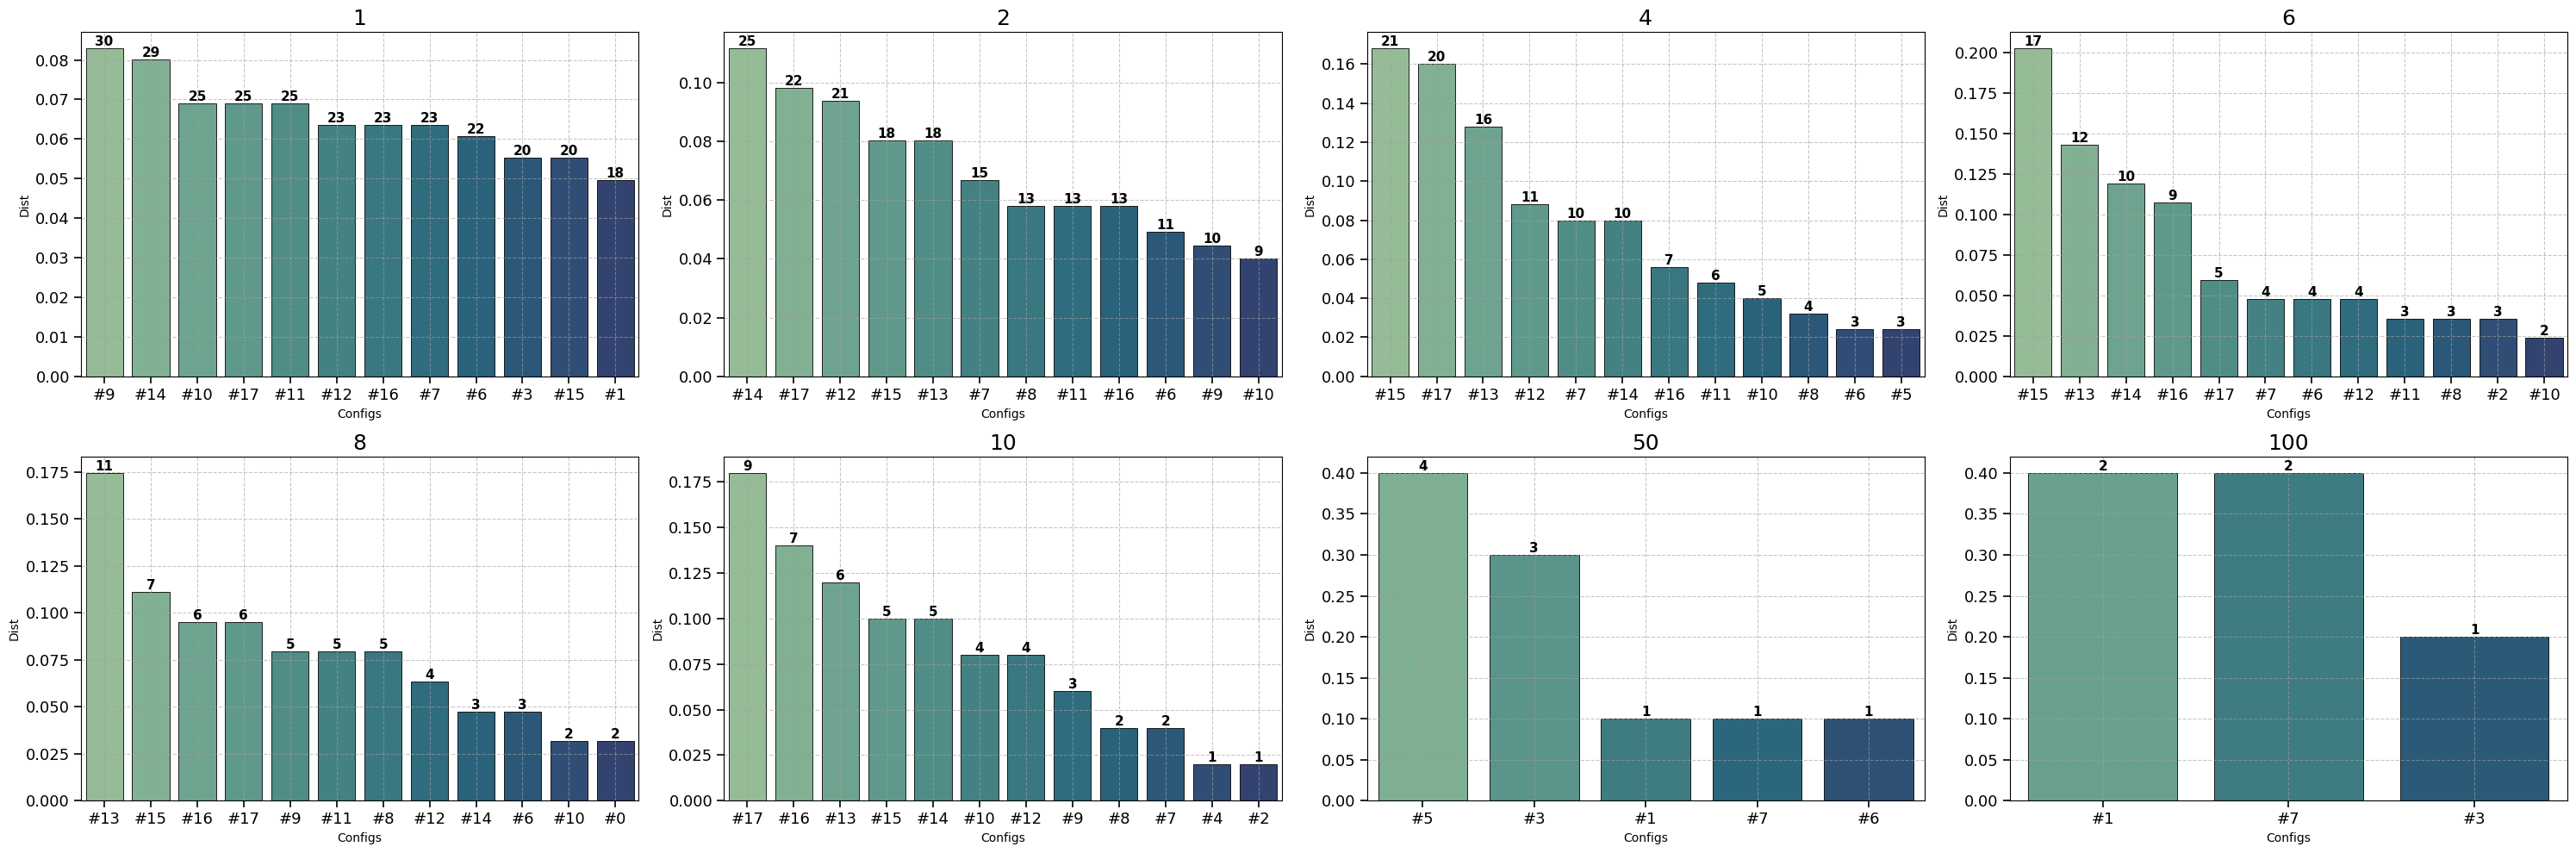

In [8]:
knn_pdt_ms = pd.read_json(base_result / "knn_pdt_query_model_selection.json")
knn_pdt_conf_dist = show_distr_conf(knn_pdt_ms)

In [9]:
knn_pdt_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:9, 2:14, 4:15, 6:15, 8:13, 10:17, 50:5, 100:1},
    "knn_pdt_query_model_selection.json",
    knn_pdt_ms,
    "KNNwPDT",
    WrapperKNNPDT,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:06<00:00, 71.61it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:25<00:00,  9.72it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [08:17<00:00, 49.79s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [13:17<00:00, 159.42s/it]


Eval


In [22]:
from ltr_utility.model_selection.retrain import retrain_evaluate

random_result = retrain_evaluate(
    train_valid=train_valid,
    test=test,
    configs={i: (None, {}) for i in [1, 2, 4, 6, 8, 10, 50, 100]},
    model=RandomRanker, name="RandomRanker")

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 6431.74it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 6110.87it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 4477.17it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 2623.24it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 1782.38it/s]


# Eval Results

In [ ]:
df_result = pd.concat([
    knn_pdt_result,
    knn_result,
    lm_result,
    mix_rtr_result,
    rtr_result,
    random_result,
], axis=0)


# Load ILMART results

In [24]:
pd.concat([
    results,
    pd.read_json(base_result / "ilmart_query_model_selection.json"),
    pd.read_json(base_result / "listnet_query_model_selection.json"),
], axis=0).to_json(base_result / "MQ2007_result.json", orient="records")

In [11]:
# Result for bloxplot
# results = []
# df_result = pd.concat([mix_rtr_result, knn_pdt_result], axis=0)
# for _, row in tqdm(df_result.iterrows(), total=len(mix_rtr_result)):
#     for k in eval_at:
#         res = evaluate(row["pred_test"], test.y, test.group_count, k=k,
#                        weight=False, aggregated=False)
#         results.append((row["model"], "test", row["qxm"], k, res))
#
# results = pd.DataFrame(results, columns=["model", "fold", "qxm", "k", "ndcg_s"])
# results.to_csv("MQ2007_noagg.csv")

100%|██████████| 24/24 [00:33<00:00,  1.39s/it]
